# Feature Sensitivity Analysis


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/BlackBox2C/blob/main/notebooks/04_feature_analysis.ipynb)
[![View on GitHub](https://img.shields.io/badge/View-GitHub-black?logo=github)](https://github.com/AxelSkrauba/BlackBox2C/blob/main/notebooks/04_feature_analysis.ipynb)


In embedded IoT systems, each sensor has a cost: purchase price, power consumption, PCB space, and maintenance. This notebook shows how to use `FeatureSensitivityAnalyzer` to answer:

> **"Which sensors can I remove without meaningfully degrading accuracy?"**

In [1]:
# !pip install blackbox2c -q  # Uncomment on Colab

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from blackbox2c.analysis import FeatureSensitivityAnalyzer
from blackbox2c import convert, ConversionConfig

# Synthetic dataset: 10 sensors, only 4 are informative
np.random.seed(42)
X, y = make_classification(
    n_samples=500, n_features=10, n_informative=4, n_redundant=3,
    n_repeated=0, n_classes=3, random_state=42
)
feature_names = [f"sensor_{i}" for i in range(10)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(f"Full model accuracy: {model.score(X_test, y_test):.4f}")

Full model accuracy: 0.7267


## 1. Sensitivity analysis

In [2]:
analyzer = FeatureSensitivityAnalyzer(n_repeats=20, random_state=42)
results  = analyzer.analyze(model, X_train, y_train, feature_names=feature_names)
print(results.summary())

Feature Sensitivity Analysis
Feature 7 (sensor_7): Impact = 0.1979 ± 0.0210 (Medium)
Feature 1 (sensor_1): Impact = 0.1361 ± 0.0106 (Medium)
Feature 4 (sensor_4): Impact = 0.0777 ± 0.0109 (Medium)
Feature 3 (sensor_3): Impact = 0.0401 ± 0.0049 (Low)
Feature 2 (sensor_2): Impact = 0.0221 ± 0.0072 (Low)
Feature 8 (sensor_8): Impact = 0.0220 ± 0.0049 (Low)
Feature 9 (sensor_9): Impact = 0.0139 ± 0.0051 (Low)
Feature 5 (sensor_5): Impact = 0.0083 ± 0.0030 (Very Low)
Feature 6 (sensor_6): Impact = 0.0041 ± 0.0029 (Very Low)
Feature 0 (sensor_0): Impact = 0.0036 ± 0.0012 (Very Low)

Recommendations:
- Consider removing 3 low-impact feature(s):
  * Feature 5 (sensor_5)
  * Feature 6 (sensor_6)
  * Feature 0 (sensor_0)
- 3 feature(s) have moderate impact


## 2. Feature importance plot

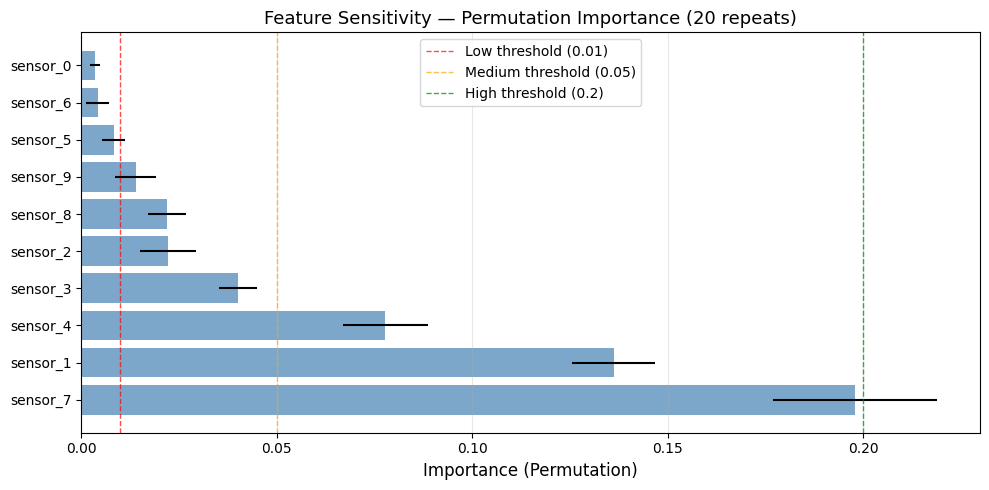

In [3]:
fig, ax = results.plot(figsize=(10, 5))
ax.set_title("Feature Sensitivity — Permutation Importance (20 repeats)", fontsize=13)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Threshold analysis — how many sensors do we need?

In [4]:
thresholds = [0.001, 0.01, 0.02, 0.05, 0.1]
rows = []
for t in thresholds:
    selected = results.get_optimal_subset(threshold=t, min_features=2)
    names    = [feature_names[i] for i in selected]
    rows.append({"Threshold": t, "# Sensors": len(selected), "Kept": ", ".join(names)})

pd.DataFrame(rows).set_index("Threshold")

,# Sensors,Kept
Threshold,,
0.001,10,"sensor_0, sensor_1, sensor_2, sensor_3, sensor..."
0.010,7,"sensor_1, sensor_2, sensor_3, sensor_4, sensor..."
0.020,6,"sensor_1, sensor_2, sensor_3, sensor_4, sensor..."
0.050,3,"sensor_1, sensor_4, sensor_7"
0.100,2,"sensor_1, sensor_7"


## 4. Reduced model — accuracy vs. code size

In [5]:
# Select features with > 2% impact
selected_idx = results.get_optimal_subset(threshold=0.02, min_features=3)
selected_names = [feature_names[i] for i in selected_idx]
print(f"Selected {len(selected_idx)}/{len(feature_names)} sensors: {selected_names}")

X_train_r = X_train[:, selected_idx]
X_test_r  = X_test[:, selected_idx]

model_r = RandomForestClassifier(n_estimators=100, random_state=42)
model_r.fit(X_train_r, y_train)

# Convert both models
cfg = ConversionConfig(max_depth=5, optimize_rules="medium")
code_full    = convert(model,   X_train,   config=cfg, feature_names=feature_names)
code_reduced = convert(model_r, X_train_r, config=cfg, feature_names=selected_names)

comparison = pd.DataFrame([
    {"Model": "Full (10 sensors)",
     "Accuracy": round(model.score(X_test, y_test), 4),
     "Flash (bytes)": len(code_full),
     "Sensors": 10},
    {"Model": f"Reduced ({len(selected_idx)} sensors)",
     "Accuracy": round(model_r.score(X_test_r, y_test), 4),
     "Flash (bytes)": len(code_reduced),
     "Sensors": len(selected_idx)},
]).set_index("Model")
comparison["Size reduction"] = (
    (1 - comparison["Flash (bytes)"] / comparison["Flash (bytes)"].iloc[0]) * 100
).round(1).astype(str) + "%"
comparison

Selected 6/10 sensors: ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8']

Starting conversion for model: RandomForestClassifier
  Task: Classification, Features: 10, Classes: 3, Max depth: 5

[1/4] Extracting surrogate decision tree...
  Surrogate fidelity: 0.7971

[2/4] Optimizing decision rules...
  Nodes: 63, Leaves: 39, Depth: 5

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 494 bytes, RAM: 32 bytes

[OK] Conversion complete!

Starting conversion for model: RandomForestClassifier
  Task: Classification, Features: 6, Classes: 3, Max depth: 5

[1/4] Extracting surrogate decision tree...
  Surrogate fidelity: 0.8000

[2/4] Optimizing decision rules...
  Nodes: 63, Leaves: 39, Depth: 5

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 494 bytes, RAM: 32 bytes

[OK] Conversion complete!


,Accuracy,Flash (bytes),Sensors,Size reduction
Model,,,,
Full (10 sensors),0.7267,3694,10,0.0%
Reduced (6 sensors),0.7000,3652,6,1.1%


## 5. Engineering implications



| Factor | Impact |
|---|---|
| **BOM cost** | Each removed sensor saves unit cost × production volume |
| **Power budget** | Fewer sensors = lower quiescent current (critical for battery-powered nodes) |
| **PCB area** | Fewer components = smaller board |
| **Firmware maintenance** | Fewer ADC channels to calibrate and validate |
| **Reliability** | Fewer failure points |

**Rule of thumb:** if removing a sensor costs less than 3% accuracy *and* the remaining accuracy meets your system's safety/QoS requirements, remove it.

Use `results.get_redundant_features(threshold=0.005)` to get a list of sensors that are safe candidates for elimination.

In [6]:
redundant = results.get_redundant_features(threshold=0.005)
print(f"Candidates for removal: {[feature_names[i] for i in redundant]}")
print("(These contribute < 0.5% to model performance)")

Candidates for removal: ['sensor_0', 'sensor_6']
(These contribute < 0.5% to model performance)
